https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

## Importing libs

In [3]:
import sys
sys.path.append('..')  # Add parent directory to path
import pandas as pd
import numpy as np
from db_setup.query import query_bigquery_table
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Importing Dummyclassifier for baseline model and logistic regression for the actual model
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Importing RandomForestClassifier and XGBClassifier for additional models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Libs to plot AUC-ROC curve
from sklearn.metrics import roc_curve, auc

# Lib for pr-AUC curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# MLflow imports
import mlflow

# NN
import torch
import torch.nn as nn
import torch.optim as optim


# Importing SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE

SEED = 42

## MLFlow settings

In [4]:
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/fase_1/Gustavo/mlruns")

In [5]:
# Set the experiment name
mlflow.set_tracking_uri("file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns")
mlflow.set_experiment("Telco-Churn-Prediction")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/11 11:18:37 INFO mlflow.tracking.fluent: Experiment with name 'Telco-Churn-Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///c:/Users/vc/Documents/MLENG_FIAP/mlruns/582674075718407240', creation_time=1775917117851, experiment_id='582674075718407240', last_update_time=1775917117851, lifecycle_stage='active', name='Telco-Churn-Prediction', tags={}, trace_location=None, workspace='default'>

## Initial Visualization of Data

In [6]:
df = query_bigquery_table()
print(df.head())

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\google\auth\_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


Iniciando a consulta...
Sucesso! 7043 linhas carregadas.
   customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0  9426-SXNHE  Female              0    False       False       2   
1  3806-YAZOV  Female              0    False       False       3   
2  3387-PLKUI  Female              0     True        True      13   
3  8992-CEUEN  Female              0    False       False       1   
4  0620-XEFWH    Male              0     True        True       4   

   PhoneService MultipleLines InternetService       OnlineSecurity  ...  \
0          True            No              No  No internet service  ...   
1          True            No              No  No internet service  ...   
2          True            No              No  No internet service  ...   
3          True            No              No  No internet service  ...   
4          True            No              No  No internet service  ...   

      DeviceProtection          TechSupport          StreamingTV  \
0  No int

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   Int64  
 3   Partner           7043 non-null   boolean
 4   Dependents        7043 non-null   boolean
 5   tenure            7043 non-null   Int64  
 6   PhoneService      7043 non-null   boolean
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   boolean


## Checking for empty, nan, null values and zeros

In [9]:
for column in df.columns:
    empty_count = df[df[column] == ""].shape[0]
    empty_space_count = df[df[column] == " "].shape[0]
    null_count = df[df[column].isnull()].shape[0]
    nan_count = df[df[column].isna()].shape[0]
    zero_count = df[df[column] == 0].shape[0]

    if empty_count > 0:
        print(f'Empty values in {column}: {empty_count}')
    if empty_space_count > 0:
        print(f'Empty spaces in {column}: {empty_space_count}')
    if null_count > 0:
        print(f'Null values in {column}: {null_count}')
    if nan_count > 0:
        print(f'Nans in {column}: {nan_count}')
    if zero_count > 0:
        print(f'Zeros in {column}: {zero_count}')

Zeros in SeniorCitizen: 5901
Zeros in Partner: 3641
Zeros in Dependents: 4933
Zeros in tenure: 11
Zeros in PhoneService: 682
Zeros in PaperlessBilling: 2872
Empty spaces in TotalCharges: 11
Zeros in Churn: 5174


In [10]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: Int64

In [11]:
df['Partner'].unique()

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

In [12]:
df['Dependents'].unique()

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

In [13]:
df['tenure'].unique()

<IntegerArray>
[ 2,  3, 13,  1,  4, 10, 20,  6,  9,  7, 12, 18, 25, 22, 27,  8, 36, 35, 11,
  5, 29, 37, 16, 61, 15, 32, 23, 31, 28, 14, 44, 46, 38, 30, 34, 17, 19, 21,
 55, 33, 26, 24, 42, 40, 41, 54, 47, 43, 51, 48, 39, 49, 50, 57, 68, 52, 59,
 64, 56, 58, 53, 60, 45, 71, 67, 65, 66, 62, 63, 69, 70, 72,  0]
Length: 73, dtype: Int64

In [14]:
df['PhoneService'].unique()

<BooleanArray>
[True, False]
Length: 2, dtype: boolean

In [15]:
df['PaperlessBilling'].unique()

<BooleanArray>
[False, True]
Length: 2, dtype: boolean

### Adjusting Total Charges

In [16]:
mean_total_charges = df[df['TotalCharges'] != ' ']['TotalCharges'].astype(float).mean()
print(f'Mean Total Charges: {mean_total_charges}')

Mean Total Charges: 2283.300440841866


In [17]:
median_total_charges = df[df['TotalCharges'] != ' ']['TotalCharges'].astype(float).median()
print(f'Median Total Charges: {median_total_charges}')

Median Total Charges: 1397.475


(array([1525.,  672.,  512.,  458.,  454.,  316.,  276.,  201.,  194.,
         170.,  179.,  159.,  147.,  162.,  145.,  136.,  159.,  117.,
         121.,  146.,  128.,  108.,  102.,  100.,   83.,   74.,   66.,
          64.,   36.,   22.]),
 array([  18.8       ,  307.66666667,  596.53333333,  885.4       ,
        1174.26666667, 1463.13333333, 1752.        , 2040.86666667,
        2329.73333333, 2618.6       , 2907.46666667, 3196.33333333,
        3485.2       , 3774.06666667, 4062.93333333, 4351.8       ,
        4640.66666667, 4929.53333333, 5218.4       , 5507.26666667,
        5796.13333333, 6085.        , 6373.86666667, 6662.73333333,
        6951.6       , 7240.46666667, 7529.33333333, 7818.2       ,
        8107.06666667, 8395.93333333, 8684.8       ]),
 <BarContainer object of 30 artists>)

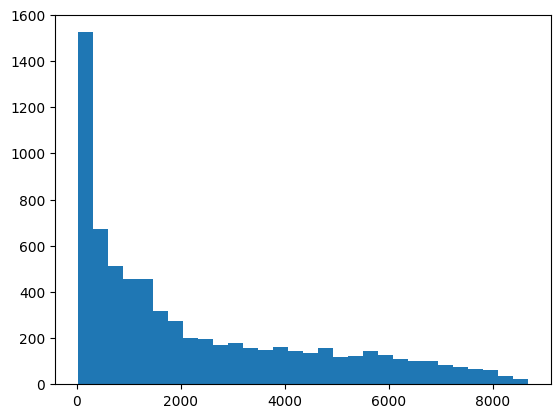

In [18]:
# Histogram of TotalCharges
plt.hist(df[df['TotalCharges'] != ' ']['TotalCharges'].astype(float), bins=30)

In [19]:
df = df[df['TotalCharges'] != ' ']

In [20]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

## Target variable distribution

In [21]:
df['Churn'].value_counts()

Churn
False    5163
True     1869
Name: count, dtype: Int64

## Checking feature distribution

In [22]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [23]:
df['TotalCharges'].astype(float).describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

Text(0.5, 1.0, 'Distribution of Monthly Charges')

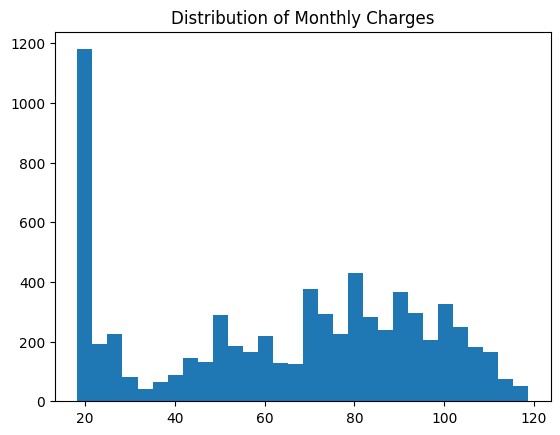

In [24]:
# Ploting a histogram of the MonthlyCharges column
plt.hist(df['MonthlyCharges'], bins=30)
plt.title('Distribution of Monthly Charges')

In [25]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [26]:
df['PaperlessBilling'].value_counts()

PaperlessBilling
True     4168
False    2864
Name: count, dtype: Int64

In [27]:
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [28]:
df['StreamingMovies'].value_counts()

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64

In [29]:
df['StreamingTV'].value_counts()

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

In [30]:
df['TechSupport'].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

In [31]:
df['DeviceProtection'].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

In [32]:
df['OnlineBackup'].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

In [33]:
df['OnlineSecurity'].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

In [34]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [35]:
df['MultipleLines'].value_counts()

MultipleLines
No                  3385
Yes                 2967
No phone service     680
Name: count, dtype: int64

In [36]:
df['PhoneService'].value_counts()

PhoneService
True     6352
False     680
Name: count, dtype: Int64

In [37]:
df['Dependents'].value_counts()

Dependents
False    4933
True     2099
Name: count, dtype: Int64

In [38]:
df['Partner'].value_counts()

Partner
False    3639
True     3393
Name: count, dtype: Int64

In [39]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: Int64

In [40]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Tenure')

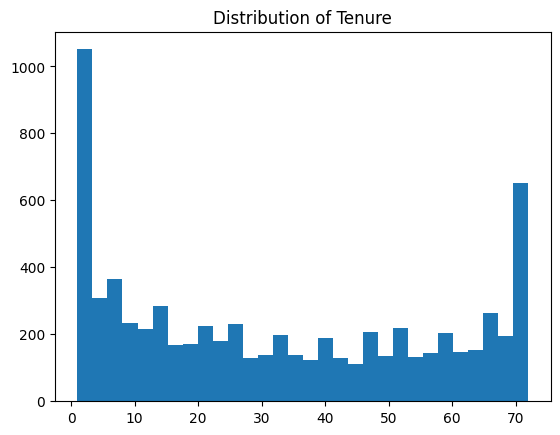

In [41]:
# Ploting a histogram of the tenure column
plt.hist(df['tenure'], bins=30)
plt.title('Distribution of Tenure')

## Onehotencoding the categorical variables

In [42]:
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

In [43]:
# Keeping only alphanumeric characters and underscores in column names
df.columns = df.columns.str.replace(r'[^a-z0-9_]', '', regex=True)

In [44]:
df.set_index('customerid', inplace=True)

In [45]:
# Check which columns are object type
object_columns = df.select_dtypes(include=['object']).columns.tolist()
print("Object type columns:")
print(object_columns)

# One-hot encoding the categorical variables
df_encoded = pd.get_dummies(df, columns=object_columns, drop_first=True)

print(f"\nOriginal shape: {df.shape}")
print(f"After one-hot encoding: {df_encoded.shape}")
print(f"\nNew columns: {df_encoded.columns.tolist()}")

Object type columns:
['gender', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paymentmethod']

Original shape: (7032, 20)
After one-hot encoding: (7032, 31)

New columns: ['seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'paperlessbilling', 'monthlycharges', 'totalcharges', 'churn', 'gender_Male', 'multiplelines_No phone service', 'multiplelines_Yes', 'internetservice_Fiber optic', 'internetservice_No', 'onlinesecurity_No internet service', 'onlinesecurity_Yes', 'onlinebackup_No internet service', 'onlinebackup_Yes', 'deviceprotection_No internet service', 'deviceprotection_Yes', 'techsupport_No internet service', 'techsupport_Yes', 'streamingtv_No internet service', 'streamingtv_Yes', 'streamingmovies_No internet service', 'streamingmovies_Yes', 'contract_One year', 'contract_Two year', 'paymentmethod_Credit card (automatic)', 'paymentmethod_Electronic check', '

In [46]:
# adding df to mlflow
df_encoded.to_parquet("./processed_data/df_encoded.parquet")
dataset = mlflow.data.from_pandas(df_encoded, source='./processed_data/df_encoded.parquet', name="df_encoded")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\data\dataset_source_registry.py:148: UserWarning: The specified dataset source can be interpreted in multiple ways: LocalArtifactDatasetSource, LocalArtifactDatasetSource. MLflow will assume that this is a LocalArtifactDatasetSource source.
  return _dataset_source_registry.resolve(


In [47]:
## Spliting the data into features and target variable
X = df_encoded.drop('churn', axis=1)

X.columns = [col.replace(' ', '_') for col in X.columns]
# keep only alphanumeric characters and underscores in column names
X.columns = X.columns.str.replace(r'[^a-z0-9_]', '', regex=True)

y = df_encoded['churn']

## Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

## Training baseline models

In [48]:
import numpy as np

def train_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # Start MLflow run
    with mlflow.start_run(run_name=f'Experiment - {model_name}'):

        train_ds = mlflow.data.from_pandas(pd.concat([X_train, y_train], axis=1), 
                                       targets=y_train.name, 
                                       name="train_data")

        test_ds = mlflow.data.from_pandas(pd.concat([X_test, y_test], axis=1),
                                       targets=y_test.name,
                                       name="test_data")
    
        # Log model parameters
        params = model.get_params()
        for param_name, param_value in params.items():
            mlflow.log_param(param_name, param_value)

        # Adding datasets
        mlflow.log_input(train_ds, "train_data")
        mlflow.log_input(test_ds, "test_data")
        
        # Train model
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        
        # AUC-ROC
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        mlflow.log_metric("roc_auc", roc_auc)
        
        # PR-AUC
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
        pr_auc = average_precision_score(y_test, y_prob)
        mlflow.log_metric("pr_auc", pr_auc)
        
        # Log features and coefficients for Logistic Regression
        if hasattr(model, 'coef_'):
            feature_names = X_train.columns.tolist()
            coefficients = model.coef_[0]
            
            # Log individual feature coefficients and odds ratios
            for feature_name, coef in zip(feature_names, coefficients):
                mlflow.log_param(f"feature_{feature_name}_coef", round(coef, 6))
                # Odds ratio = exp(coefficient)
                odds_ratio = np.exp(coef)
                mlflow.log_param(f"feature_{feature_name}_odds_ratio", round(odds_ratio, 6))
            
            # Log intercept
            mlflow.log_param("intercept", round(model.intercept_[0], 6))
            
            # Create and log a summary artifact with feature importance
            feature_summary = pd.DataFrame({
                'Feature': feature_names,
                'Coefficient': coefficients,
                'Odds_Ratio': np.exp(coefficients)
            }).sort_values('Coefficient', ascending=False)
            
            # Save as CSV artifact
            feature_summary.to_csv('./tmp/feature_coefficients.csv', index=False)
            mlflow.log_artifact('./tmp/feature_coefficients.csv', artifact_path='feature_analysis')
            
            print(f"\nFeature Coefficients and Odds Ratios:")
            print(feature_summary)
        
        # Log model
        mlflow.sklearn.log_model(model, name=model_name)

        # Register model in MLflow Model Registry
        mlflow.register_model(f"runs:/{mlflow.active_run().info.run_id}/{model_name}", model_name)
        
        # Print results
        print(f"\n{model.__class__.__name__} Performance:")
        print(f'Accuracy: {accuracy:.4f}')
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
        print(classification_report(y_test, y_pred))
    
    

In [49]:
# Training a Dummy Classifier as a baseline model
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=SEED)

train_model(dummy_clf, X_train, y_train, X_test, y_test, model_name="Dummy Classifier")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\


DummyClassifier Performance:
Accuracy: 0.7342
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC-AUC: 0.5000
PR-AUC: 0.2658
              precision    recall  f1-score   support

         0.0       0.73      1.00      0.85      1033
         1.0       0.00      0.00      0.00       374

    accuracy                           0.73      1407
   macro avg       0.37      0.50      0.42      1407
weighted avg       0.54      0.73      0.62      1407



Created version '1' of model 'Dummy Classifier'.
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\sit

In [ ]:
## Training a Logistic Regression model
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED)

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression")


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_m


Feature Coefficients and Odds Ratios:
                                Feature  Coefficient  Odds_Ratio
11           internetservice_iber_optic     0.607657    1.836124
5                      paperlessbilling     0.402490    1.495544
28        paymentmethod_lectronic_check     0.383706    1.467713
0                         seniorcitizen     0.231692    1.260732
22                       streamingtv_es     0.230325    1.259009
10                     multiplelines_es     0.224795    1.252066
24                   streamingmovies_es     0.216992    1.242334
9         multiplelines_o_phone_service     0.191534    1.211106
8                            gender_ale     0.008563    1.008600
6                        monthlycharges     0.003377    1.003383
7                          totalcharges     0.000341    1.000341
29            paymentmethod_ailed_check    -0.007911    0.992120
1                               partner    -0.009628    0.990418
3                                tenure    -0.06301

2026/04/11 11:19:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
## Training a Logistic Regression model and adding class_weight='balanced' to handle class imbalance
logreg_clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')

train_model(logreg_clf, X_train, y_train, X_test, y_test, model_name="Logistic Regression with Class Weight")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_m


Feature Coefficients and Odds Ratios:
                                Feature  Coefficient  Odds_Ratio
9         multiplelines_o_phone_service     0.448528    1.566005
28        paymentmethod_lectronic_check     0.407682    1.503329
5                      paperlessbilling     0.387757    1.473672
11           internetservice_iber_optic     0.328093    1.388318
0                         seniorcitizen     0.230724    1.259511
22                       streamingtv_es     0.148596    1.160204
10                     multiplelines_es     0.135065    1.144611
24                   streamingmovies_es     0.122960    1.130840
8                            gender_ale     0.026152    1.026497
6                        monthlycharges     0.013751    1.013846
7                          totalcharges     0.000303    1.000303
29            paymentmethod_ailed_check    -0.006886    0.993138
1                               partner    -0.025889    0.974443
3                                tenure    -0.05741

2026/04/11 11:00:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression with Class Weight' already exists. Creating a new version of this model...
2026/04/11 11:00:46 WARNING mlflow.tracking._model_registry.fluent: Run with id 16240ca877224f7a8f9af386b002e04b has no artifacts at artifact path 'Logistic Regression with Class Weight', registering model based on models:/m-386635e985284b0f9602743ad1cc4cbb instead
Created version '3' of model 'Logistic Regression with Class Weight'.



LogisticRegression Performance:
Accuracy: 0.7427
Precision: 0.5104
Recall: 0.7861
F1 Score: 0.6189
ROC-AUC: 0.8398
PR-AUC: 0.6494
              precision    recall  f1-score   support

         0.0       0.90      0.73      0.81      1033
         1.0       0.51      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407



## Handling Imbalanced Data with SMOTE

In [ ]:
smote = SMOTE(random_state=SEED)

# Convert X_train and y_train to float64/int to avoid casting issues with SMOTE
X_train_float = X_train.astype('float64')
y_train_int = y_train.astype('int')

X_train_smote, y_train_smote = smote.fit_resample(X_train_float, y_train_int)

# Convert back to DataFrame with original column names
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train.columns)

logreg_clf_smote = LogisticRegression(max_iter=1000, random_state=SEED)
train_model(logreg_clf_smote, X_train_smote, y_train_smote, X_test, y_test.astype(int), model_name="Logistic Regression with SMOTE")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(



Feature Coefficients and Odds Ratios:
                                Feature  Coefficient  Odds_Ratio
9         multiplelines_o_phone_service     0.527587    1.694838
28        paymentmethod_lectronic_check     0.492647    1.636643
5                      paperlessbilling     0.437789    1.549277
11           internetservice_iber_optic     0.343166    1.409403
0                         seniorcitizen     0.218961    1.244783
10                     multiplelines_es     0.179130    1.196177
24                   streamingmovies_es     0.117860    1.125086
29            paymentmethod_ailed_check     0.101704    1.107055
22                       streamingtv_es     0.070957    1.073536
8                            gender_ale     0.039754    1.040555
6                        monthlycharges     0.013161    1.013248
7                          totalcharges     0.000493    1.000493
1                               partner    -0.037962    0.962749
3                                tenure    -0.07353

2026/04/11 11:00:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'Logistic Regression with SMOTE' already exists. Creating a new version of this model...
2026/04/11 11:00:56 WARNING mlflow.tracking._model_registry.fluent: Run with id 3999c1ac597d4ec2bf6a1049aa272e8a has no artifacts at artifact path 'Logistic Regression with SMOTE', registering model based on models:/m-ac1bdc5cd55745d6938a9f038b465b21 instead
Created version '2' of model 'Logistic Regression with SMOTE'.



LogisticRegression Performance:
Accuracy: 0.7491
Precision: 0.5183
Recall: 0.7941
F1 Score: 0.6272
ROC-AUC: 0.8404
PR-AUC: 0.6539
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1033
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



## Adding other models

In [ ]:
# XGBoost Classifier
xgb_clf = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')
train_model(xgb_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="XGBoost Classifier")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training


XGBClassifier Performance:
Accuracy: 0.7818
Precision: 0.6018
Recall: 0.5294
F1 Score: 0.5633
ROC-AUC: 0.8160
PR-AUC: 0.6128
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1033
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



In [ ]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=SEED)
train_model(rf_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="Random Forest Classifier")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/11 11:01:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these for


RandomForestClassifier Performance:
Accuracy: 0.7918
Precision: 0.6401
Recall: 0.4947
F1 Score: 0.5581
ROC-AUC: 0.8211
PR-AUC: 0.6302
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



Created version '2' of model 'Random Forest Classifier'.


In [ ]:
# Random Search CV for Hyperparameter Tuning of XGBoost

random_search_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_clf_random = XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss')
random_search = RandomizedSearchCV(estimator=xgb_clf_random, param_distributions=random_search_params, n_iter=10, cv=3, verbose=2, random_state=SEED, n_jobs=-1)

random_search.fit(X_train, y_train.astype(int))

print(f"Best parameters found: {random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [11:01:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
# Using the best estimator from random search to train and evaluate
best_xgb_clf = random_search.best_estimator_
train_model(best_xgb_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="XGBoost Classifier with Random Search CV")

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training


XGBClassifier Performance:
Accuracy: 0.8088
Precision: 0.6733
Recall: 0.5455
F1 Score: 0.6027
ROC-AUC: 0.8453
PR-AUC: 0.6759
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1033
           1       0.67      0.55      0.60       374

    accuracy                           0.81      1407
   macro avg       0.76      0.72      0.74      1407
weighted avg       0.80      0.81      0.80      1407



Created version '2' of model 'XGBoost Classifier with Random Search CV'.


In [ ]:
# Random search for Random Forest Classifier
rf_random_search_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_clf_random = RandomForestClassifier(random_state=SEED)
rf_random_search = RandomizedSearchCV(estimator=rf_clf_random, param_distributions=rf_random_search_params, n_iter=10, cv=3, verbose=2, random_state=SEED, n_jobs=-1)

rf_random_search.fit(X_train, y_train.astype(int))
print(f"Best parameters found for Random Forest: {rf_random_search.best_params_}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 10, 'bootstrap': True}


In [ ]:
# Training a Random Forest Classifier with best parameters from random search
best_rf_clf = rf_random_search.best_estimator_
train_model(best_rf_clf, X_train, y_train.astype(int), X_test, y_test.astype(int), model_name="Random Forest Classifier with Random Search CV")


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/11 11:02:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these for


RandomForestClassifier Performance:
Accuracy: 0.8053
Precision: 0.6656
Recall: 0.5374
F1 Score: 0.5947
ROC-AUC: 0.8354
PR-AUC: 0.6673
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.67      0.54      0.59       374

    accuracy                           0.81      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.80      0.81      0.80      1407



Created version '2' of model 'Random Forest Classifier with Random Search CV'.


## Creating Neural Network with PyTorch

In [ ]:
# Creating Neural Network with PyTorch

class SimpleChurnNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleChurnNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

def train_and_evaluate_nn(X_train, y_train, X_test, y_test, model_name="Neural Network", 
                          num_epochs=100, patience=10, min_delta=0.0001, val_split=0.2,
                          learning_rate=0.001, batch_size=32, log_to_mlflow=True, NN=SimpleChurnNN):
    """
    Train and evaluate a neural network with early stopping and batch processing.
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features
    y_train : pd.Series
        Training labels
    X_test : pd.DataFrame
        Test features
    y_test : pd.Series
        Test labels
    model_name : str
        Name of the model for logging
    num_epochs : int
        Maximum number of epochs
    patience : int
        Number of epochs with no improvement before early stopping
    min_delta : float
        Minimum improvement threshold
    val_split : float
        Validation split ratio (0.2 = 20%)
    learning_rate : float
        Learning rate for Adam optimizer
    batch_size : int
        Batch size for training and validation (default: 32)
    log_to_mlflow : bool
        Whether to log results to MLflow
    NN : class
        Neural network architecture class
    
    Returns:
    --------
    dict : Dictionary containing model, metrics, and training info
    """
    from torch.utils.data import DataLoader, TensorDataset
    
    # Convert data to float32
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')
    
    # Create validation split
    val_size = int(len(X_train) * val_split)
    X_train_split = X_train.iloc[:-val_size]
    X_val_split = X_train.iloc[-val_size:]
    y_train_split = y_train.iloc[:-val_size]
    y_val_split = y_train.iloc[-val_size:]
    
    # Convert to tensors
    X_train_tensor = torch.tensor(X_train_split.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_split.values, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val_split.values, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_split.values, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

    # Create DataLoaders for batch processing
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    if log_to_mlflow:
        with mlflow.start_run(run_name=f'Experiment - {model_name}'):
            train_ds = mlflow.data.from_pandas(pd.concat([X_train_split, y_train_split], axis=1), 
                                            targets=y_train_split.name, 
                                            name="nn_train_data")
            
            val_ds = mlflow.data.from_pandas(pd.concat([X_val_split, y_val_split], axis=1),
                                            targets=y_val_split.name,
                                            name="nn_val_data")
            
            test_ds = mlflow.data.from_pandas(pd.concat([X_test, y_test], axis=1),
                                            targets=y_test.name,
                                            name="nn_test_data")
            mlflow.log_input(train_ds, "nn_train_data")
            mlflow.log_input(val_ds, "nn_val_data")
            mlflow.log_input(test_ds, "nn_test_data")

            # Calculate weight: count_negative / count_positive
            num_pos = torch.sum(y_train_tensor == 1).float()
            num_neg = torch.sum(y_train_tensor == 0).float()

            # Add a small epsilon to avoid division by zero
            pos_weight = num_neg / (num_pos + 1e-8)

            # Convert to a tensor (BCEWithLogitsLoss expects a tensor)
            pos_weight_tensor = torch.tensor([pos_weight])

            # Initialize the loss function with the dynamic weight
            criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
            
            # Initialize model
            input_dim = X_train.shape[1]
            model = NN(input_dim)
            optimizer = optim.Adam(model.parameters(), lr=learning_rate)
            
            # Training variables
            best_val_loss = float('inf')
            patience_counter = 0
            train_losses = []
            val_losses = []
            best_model_state = None
            epochs_trained = 0
            
            # Training loop with early stopping
            for epoch in range(num_epochs):
                # Training phase - process batches
                model.train()
                epoch_train_loss = 0.0
                num_batches = 0
                
                for X_batch, y_batch in train_loader:
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    loss.backward()
                    optimizer.step()
                    epoch_train_loss += loss.item()
                    num_batches += 1
                
                avg_train_loss = epoch_train_loss / num_batches
                train_losses.append(avg_train_loss)
                
                # Validation phase - process batches
                model.eval()
                epoch_val_loss = 0.0
                val_num_batches = 0
                
                with torch.no_grad():
                    for X_batch, y_batch in val_loader:
                        val_outputs = model(X_batch)
                        val_loss = criterion(val_outputs, y_batch)
                        epoch_val_loss += val_loss.item()
                        val_num_batches += 1
                
                avg_val_loss = epoch_val_loss / val_num_batches
                val_losses.append(avg_val_loss)
                
                # Early stopping check
                if avg_val_loss < best_val_loss - min_delta:
                    best_val_loss = avg_val_loss
                    patience_counter = 0
                    best_model_state = model.state_dict().copy()
                else:
                    patience_counter += 1
                
                # Print progress every 5 epochs
                if (epoch+1) % 5 == 0:
                    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
                
                # Stop if patience exceeded
                if patience_counter >= patience:
                    print(f'\nEarly stopping triggered at epoch {epoch+1}. Best validation loss: {best_val_loss:.4f}')
                    model.load_state_dict(best_model_state)
                    epochs_trained = epoch + 1
                    break
                
                epochs_trained = epoch + 1
            
            print(f'Training completed. Total epochs trained: {epochs_trained}')
            
            # Evaluate the model - process batches
            model.eval()
            y_pred_prob_list = []
            
            with torch.no_grad():
                for X_batch, _ in test_loader:
                    batch_pred = model(X_batch).numpy()
                    y_pred_prob_list.append(batch_pred)
            
            y_pred_prob = np.vstack(y_pred_prob_list)
            y_pred = (y_pred_prob > 0.5).astype(int)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            precision = precision_score(y_test, y_pred)
            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred)
            roc_auc = auc(*roc_curve(y_test, y_pred_prob)[0:2])
            pr_auc = average_precision_score(y_test, y_pred_prob)
            
            print(f'\n{model_name} Performance:')
            print(f'Accuracy: {accuracy:.4f}')
            print(f'Precision: {precision:.4f}')
            print(f'Recall: {recall:.4f}')
            print(f'F1 Score: {f1:.4f}')
            print(f'ROC-AUC: {roc_auc:.4f}')
            print(f'PR-AUC: {pr_auc:.4f}')
            
            # Log to MLflow if requested
    
            mlflow.log_param("model_type", model_name)
            mlflow.log_param("patience", patience)
            mlflow.log_param("learning_rate", learning_rate)
            mlflow.log_param("batch_size", batch_size)
            mlflow.log_param("epochs_trained", epochs_trained)
            mlflow.log_metric("accuracy", accuracy)
            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_score", f1)
            mlflow.log_metric("roc_auc", roc_auc)
            mlflow.log_metric("pr_auc", pr_auc)
            mlflow.log_metric("best_val_loss", best_val_loss)
            
            mlflow.pytorch.log_model(model, model_name)
            mlflow.register_model(f"runs:/{mlflow.active_run().info.run_id}/" + model_name, model_name)
    
    # Return results
    return {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'best_val_loss': best_val_loss,
        'epochs_trained': epochs_trained,
        'y_pred': y_pred,
        'y_pred_prob': y_pred_prob
    }



In [ ]:
# Train the neural network
nn_results = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test, 
                                    model_name="Neural Network with SMOTE", NN=SimpleChurnNN)


C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Epoch [5/100], Train Loss: 0.8133, Val Loss: 0.7043
Epoch [10/100], Train Loss: 0.7963, Val Loss: 0.7537
Epoch [15/100], Train Loss: 0.7975, Val Loss: 0.7377


2026/04/11 11:07:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping triggered at epoch 17. Best validation loss: 0.5399
Training completed. Total epochs trained: 17

Neural Network with SMOTE Performance:
Accuracy: 0.7448
Precision: 0.5155
Recall: 0.6684
F1 Score: 0.5821
ROC-AUC: 0.7654
PR-AUC: 0.5356


2026/04/11 11:07:43 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'Neural Network with SMOTE' already exists. Creating a new version of this model...
2026/04/11 11:07:54 WARNING mlflow.tracking._model_registry.fluent: Run with id d18f70935fb341fd9bab4ff24b0b386e has no artifacts at artifact path 'Neural Network with SMOTE', registering model based on models:/m-aa678dfdfc7a4947b0998a08f90f58d7 instead
Created version '5' of model 'Neural Network with SMOTE'.


In [ ]:
class LogisticRegressionNN(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegressionNN, self).__init__()
        # One linear layer: input_dim -> 1 output
        self.linear = nn.Linear(input_dim, 1)
        
    def forward(self, x):
        # Sigmoid squashes the output between 0 and 1 (probability)
        return torch.sigmoid(self.linear(x))

In [ ]:
nn_results_logreg = train_and_evaluate_nn(X_train_smote, y_train_smote, X_test, y_test,
                                         model_name="Logistic Regression NN with SMOTE", NN=LogisticRegressionNN)

C:\Users\vc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Epoch [5/100], Train Loss: 0.7907, Val Loss: 0.8383
Epoch [10/100], Train Loss: 0.7881, Val Loss: 0.8140


2026/04/11 11:08:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



Early stopping triggered at epoch 14. Best validation loss: 0.6974
Training completed. Total epochs trained: 14

Logistic Regression NN with SMOTE Performance:
Accuracy: 0.7733
Precision: 0.5624
Recall: 0.6631
F1 Score: 0.6086
ROC-AUC: 0.8151
PR-AUC: 0.6487


2026/04/11 11:08:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'Logistic Regression NN with SMOTE' already exists. Creating a new version of this model...
2026/04/11 11:08:30 WARNING mlflow.tracking._model_registry.fluent: Run with id 924a7675bdbc4d4195dda7c47d949903 has no artifacts at artifact path 'Logistic Regression NN with SMOTE', registering model based on models:/m-af5ed392a3ce413ab42857a00dd714e6 instead
Created version '3' of model 'Logistic Regression NN with SMOTE'.


In [ ]:
nn_results_logreg = train_and_evaluate_nn(X_train, y_train, X_test, y_test,
                                         model_name="Logistic Regression NN", NN=LogisticRegressionNN)

Epoch [5/100], Train Loss: 0.9508, Val Loss: 0.9562
Epoch [10/100], Train Loss: 0.9305, Val Loss: 0.9382
Epoch [15/100], Train Loss: 0.9284, Val Loss: 0.9373
Epoch [20/100], Train Loss: 0.9229, Val Loss: 0.9366
Epoch [25/100], Train Loss: 0.9251, Val Loss: 0.9352
Epoch [30/100], Train Loss: 0.9215, Val Loss: 0.9304
Epoch [35/100], Train Loss: 0.9210, Val Loss: 0.9236
Epoch [40/100], Train Loss: 0.9187, Val Loss: 0.9293
Epoch [45/100], Train Loss: 0.9185, Val Loss: 0.9208
Epoch [50/100], Train Loss: 0.9167, Val Loss: 0.9600
Epoch [55/100], Train Loss: 0.9107, Val Loss: 0.9207
Epoch [60/100], Train Loss: 0.9126, Val Loss: 0.9088
Epoch [65/100], Train Loss: 0.9144, Val Loss: 0.9165
Epoch [70/100], Train Loss: 0.9178, Val Loss: 0.9084
Epoch [75/100], Train Loss: 0.9094, Val Loss: 0.9057
Epoch [80/100], Train Loss: 0.9111, Val Loss: 0.9188
Epoch [85/100], Train Loss: 0.9097, Val Loss: 0.9133
Epoch [90/100], Train Loss: 0.9150, Val Loss: 0.9131
Epoch [95/100], Train Loss: 0.9162, Val Loss: 0

2026/04/11 11:09:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch [100/100], Train Loss: 0.9078, Val Loss: 0.9037
Training completed. Total epochs trained: 100

Logistic Regression NN Performance:
Accuracy: 0.7861
Precision: 0.5863
Recall: 0.6631
F1 Score: 0.6223
ROC-AUC: 0.8319
PR-AUC: 0.6653


2026/04/11 11:09:01 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
Registered model 'Logistic Regression NN' already exists. Creating a new version of this model...
2026/04/11 11:09:14 WARNING mlflow.tracking._model_registry.fluent: Run with id bbda3fe228114d689de0a3b74cd1eb55 has no artifacts at artifact path 'Logistic Regression NN', registering model based on models:/m-296dd038596a4bc8a6f04a487c5f16db instead
Created version '3' of model 'Logistic Regression NN'.
